In [ ]:
import json
import os
import numpy as np
import json
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoModel
import torch
import re
import copy
import pandas as pd



In [5]:

with open("../../LLMOnly/llama3.1-8b_clean_fake_dataset/result.json","r",encoding="utf-8") as f:
    data = json.load(f)
non_hallucination_results = [
    r for r in data["results"]
    if "i don't know" in r["prediction"].strip().lower()
]

hallucination_results = [
    r for r in data["results"]
    if "i don't know" not in r["prediction"].strip().lower()
]





In [6]:
print(len(hallucination_results))

len(non_hallucination_results)


255


2398

In [7]:
len(non_hallucination_results)

2398

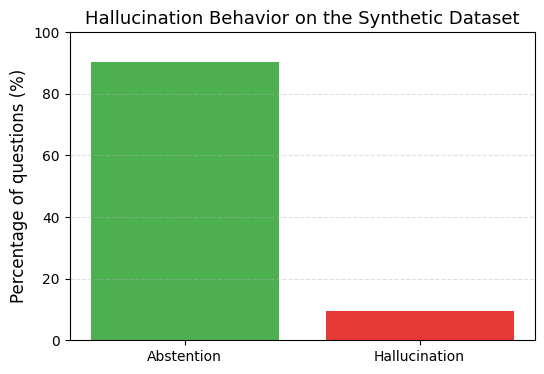

In [14]:
import matplotlib.pyplot as plt

hallucination_count = len(hallucination_results)
non_hallucination_count = len(non_hallucination_results)
total = hallucination_count + non_hallucination_count

labels = ["Abstention", "Hallucination"]
values = [
    non_hallucination_count / total * 100,
    hallucination_count / total * 100
]

colors = ["#4CAF50", "#E53935"]  # vert / rouge

plt.figure(figsize=(6, 4))

bars = plt.bar(labels, values, color=colors)

plt.ylabel("Percentage of questions (%)", fontsize=12)
plt.title("Hallucination Behavior on the Synthetic Dataset", fontsize=13)

plt.ylim(0, 100)
"""
# légende seulement
plt.legend(
    bars,
    ["Abstention (I don't know)", "Hallucination"],
    loc="upper right"
)
"""
# optionnel (recommandé ACL)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

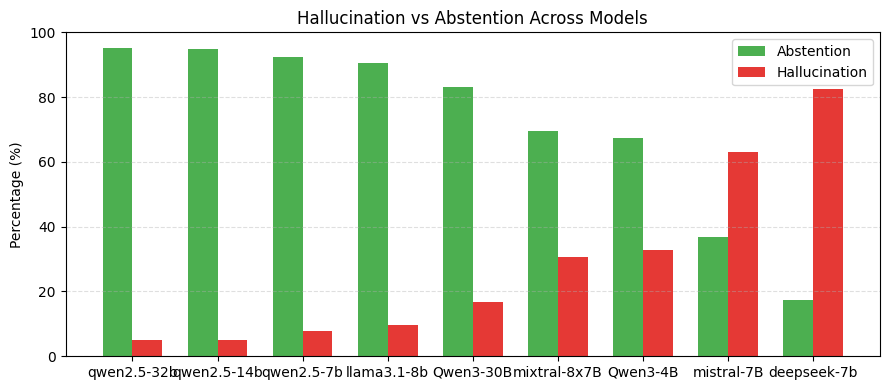

In [17]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

MODEL_NAMES = [
    "llama3.1-8b",
    "qwen2.5-7b",
    "qwen2.5-14b",
    "qwen2.5-32b",
    "mistral-7B",
    "mixtral-8x7B",
    "deepseek-7b",
    "Qwen3-30B",
    "Qwen3-4B"
]



BASE_PATH = "../../LLMOnly"


def is_idk(pred):
    pred = pred.strip().lower().replace("’", "'")
    return "i don't know" in pred


def compute_results(model_name):
    path = os.path.join(
        BASE_PATH,
        f"{model_name}_clean_fake_dataset",
        "result.json"
    )

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    non_hall = sum(1 for r in data["results"] if is_idk(r["prediction"]))
    hall = sum(1 for r in data["results"] if not is_idk(r["prediction"]))

    return non_hall, hall


def plot_models(models_results, save_path=None):
    model_names = list(models_results.keys())

    abstention = []
    hallucination = []

    for m in model_names:
        non_h, hall = models_results[m]
        total = non_h + hall

        abstention.append(non_h / total * 100)
        hallucination.append(hall / total * 100)

    x = np.arange(len(model_names))
    width = 0.35

    plt.figure(figsize=(9, 4))

    plt.bar(x - width/2, abstention, width, label="Abstention", color="#4CAF50")
    plt.bar(x + width/2, hallucination, width, label="Hallucination", color="#E53935")

    plt.xticks(x, model_names, rotation=0)
    plt.ylabel("Percentage (%)")
    plt.title("Hallucination vs Abstention Across Models")

    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.legend(loc="upper right")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


# 🔥 RUN ALL
models_results = {}

for model in MODEL_NAMES:
    non_h, hall = compute_results(model)
    models_results[model] = (non_h, hall)

# optionnel: trier par hallucination
models_results = dict(
    sorted(models_results.items(), key=lambda x: x[1][1])
)

plot_models(models_results, save_path="comparison_acl.png")

In [10]:
with open("../../LLMOnly/deepseek-7b_clean_fake_dataset/result.json","r",encoding="utf-8") as f:
    data=json.load(f)


In [11]:
rows = []

for model, (abstention_count, hallucination_count) in models_results.items():
    total = abstention_count + hallucination_count

    rows.append({
        "Model": model,
        "Total questions":total,
        "Abstention_Count": abstention_count,
        "Hallucination_Count": hallucination_count,
        "Abstention_%": round(abstention_count / total * 100, 2),
        "Hallucination_%": round(hallucination_count / total * 100, 2)
    })

df = pd.DataFrame(rows)

# Trier par hallucination
df = df.sort_values("Hallucination_%")

df

,Model,Total questions,Abstention_Count,Hallucination_Count,Abstention_%,Hallucination_%
0,qwen2.5-32b,2653,2521,132,95.02,4.98
1,qwen2.5-14b,2653,2519,134,94.95,5.05
2,qwen2.5-7b,2653,2449,204,92.31,7.69
3,llama3.1-8b,2653,2398,255,90.39,9.61
4,Qwen3-30B,2653,2207,446,83.19,16.81
5,mixtral-8x7B,2653,1842,811,69.43,30.57
6,Qwen3-4B,2653,1785,868,67.28,32.72
7,mistral-7B,2653,978,1675,36.86,63.14
8,deepseek-7b,2653,463,2190,17.45,82.55


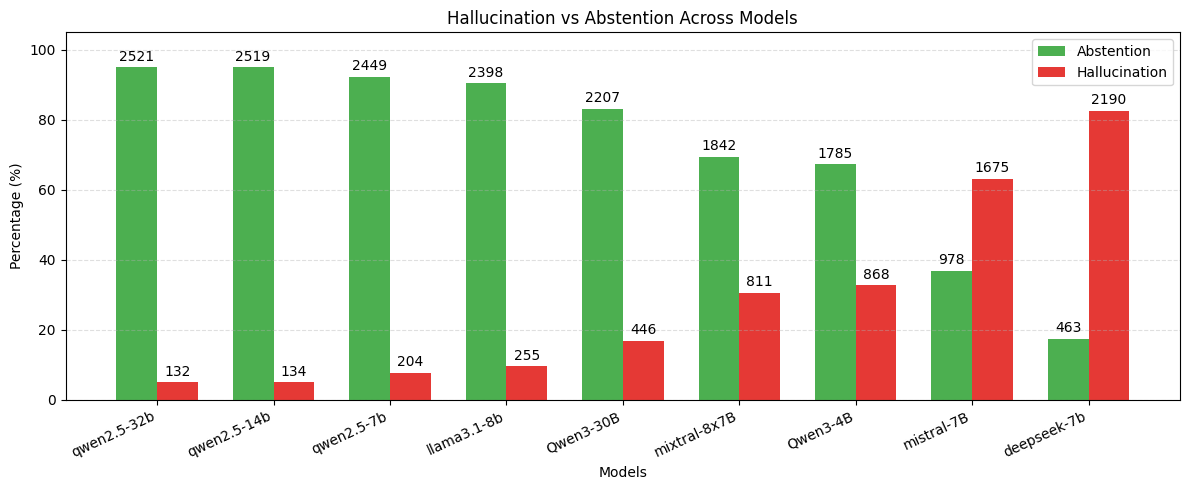

In [18]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

MODEL_NAMES = [
    "llama3.1-8b",
    "qwen2.5-7b",
    "qwen2.5-14b",
    "qwen2.5-32b",
    "mistral-7B",
    "mixtral-8x7B",
    "deepseek-7b",
    "Qwen3-30B",
    "Qwen3-4B"
]

BASE_PATH = "../../LLMOnly"


def is_idk(pred):
    pred = pred.strip().lower().replace("’", "'")
    return "i don't know" in pred


def compute_results(model_name):
    path = os.path.join(
        BASE_PATH,
        f"{model_name}_clean_fake_dataset",
        "result.json"
    )

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    abstention = sum(
        1 for r in data["results"]
        if is_idk(r["prediction"])
    )

    hallucination = sum(
        1 for r in data["results"]
        if not is_idk(r["prediction"])
    )

    return abstention, hallucination


def plot_models(models_results, save_path=None):

    model_names = list(models_results.keys())

    abstention_pct = []
    hallucination_pct = []

    abstention_count = []
    hallucination_count = []

    for m in model_names:
        abst, hall = models_results[m]
        total = abst + hall

        abstention_count.append(abst)
        hallucination_count.append(hall)

        abstention_pct.append(abst / total * 100)
        hallucination_pct.append(hall / total * 100)

    x = np.arange(len(model_names))
    width = 0.35

    plt.figure(figsize=(12, 5))

    bars1 = plt.bar(
        x - width / 2,
        abstention_pct,
        width,
        label="Abstention",
        color="#4CAF50"
    )

    bars2 = plt.bar(
        x + width / 2,
        hallucination_pct,
        width,
        label="Hallucination",
        color="#E53935"
    )

    # Afficher uniquement le nombre de questions
    for bar, count in zip(bars1, abstention_count):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            str(count),
            ha='center',
            va='bottom',
            fontsize=10
        )

    for bar, count in zip(bars2, hallucination_count):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            str(count),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.xticks(x, model_names, rotation=25, ha="right")

    plt.ylabel("Percentage (%)")
    plt.xlabel("Models")

    plt.title("Hallucination vs Abstention Across Models")

    plt.ylim(0, 105)

    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    plt.legend(loc="upper right")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# Exécution
models_results = {}

for model in MODEL_NAMES:
    abst, hall = compute_results(model)
    models_results[model] = (abst, hall)

# Trier par nombre d'hallucinations croissant
models_results = dict(
    sorted(
        models_results.items(),
        key=lambda x: x[1][1]
    )
)

plot_models(
    models_results,
    save_path="comparison.png"
)